# Model Training - 10 Models Benchmarked

**Razorpay AI Buildathon 2026 - Track 02: AI Risk Manager**

Return-Risk Scorer for COD orders (Return-to-Origin prediction).

---

### The rules this benchmark runs under

Ten models plus a majority-class baseline. **Same folds, same seed, same features,
same preprocessing** — every entry gets light, documented defaults. Handing one model
a tuned configuration and the rest their library defaults would make the leaderboard
a statement about effort, not about models. Tuning happens in `04`, on the finalists
only.

Ranked on **validation PR-AUC**, fixed in `PRE_REGISTRATION.md` before any model
existed. Reported alongside: ROC-AUC, **Brier score** and log-loss, because the
operating threshold in `05` is chosen on a rupee cost curve and a cost curve built on
badly calibrated scores is fiction.

**Accuracy appears nowhere.** On a 15.5% validation base rate, predicting "no RTO"
forever scores 84.5%.

**The test set is not opened in this notebook.**

### Two things this notebook must be willing to conclude

1. That gradient boosting does not beat logistic regression. `PRE_REGISTRATION.md`
   commits to reporting that if it happens.
2. That the gap between two models is **noise**. A 0.003 PR-AUC difference on 5,000
   validation orders is not evidence. Section 14 runs a paired bootstrap rather than
   reading the leaderboard order as fact.

## 1. Load train/val

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluate import (
    classification_metrics,
    expanding_window_cv,
    paired_bootstrap_delta,
)
from src.features import TARGET
from src.models import SEED, build_pipeline, model_input_columns, model_zoo

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

FIG = ROOT / "reports/figures"
RES = ROOT / "reports/results"
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)

N_CV_FOLDS = 5

In [2]:
def load_split(name: str) -> pd.DataFrame:
    if name == "test":
        raise PermissionError(
            "03_model_training may not read the test split. It is opened once, "
            "in 05_final_evaluation.ipynb, after the final model is selected."
        )
    return pd.read_parquet(ROOT / f"data/processed/{name}.parquet")


train = load_split("train")
val = load_split("val")
COLS = model_input_columns()

y_train = train[TARGET].to_numpy()
y_val = val[TARGET].to_numpy()

print(f"train {len(train):>6,}  {train.order_ts.min():%Y-%m-%d} -> {train.order_ts.max():%Y-%m-%d}  base {y_train.mean():.4f}")
print(f"val   {len(val):>6,}  {val.order_ts.min():%Y-%m-%d} -> {val.order_ts.max():%Y-%m-%d}  base {y_val.mean():.4f}")
print(f"\nfeature columns fed to the pipeline: {len(COLS)}")

assert train.order_ts.max() <= val.order_ts.min(), "split is not chronological"
try:
    load_split("test")
except PermissionError as exc:
    print(f"\nguard active -> {exc}")

train 35,000  2024-01-01 -> 2025-01-22  base 0.1696
val    5,000  2025-01-22 -> 2025-03-16  base 0.1550

feature columns fed to the pipeline: 32

guard active -> 03_model_training may not read the test split. It is opened once, in 05_final_evaluation.ipynb, after the final model is selected.


In [3]:
# The validation Bayes ceiling. `_p_rto_true` is a generator LATENT: it is
# forbidden as a feature and is never fed to any model. It is read here purely
# as an oracle reference, so the leaderboard can be read against what is
# actually achievable rather than against 1.0.
latents = pd.read_csv(ROOT / "data/interim/latents.csv")
val_oracle = val[["order_id"]].merge(latents, on="order_id", how="left")["_p_rto_true"]

CEILING = classification_metrics(y_val, val_oracle)
print("Bayes ceiling on THIS validation split (oracle, not a model):")
print(f"  PR-AUC  {CEILING['pr_auc']:.4f}")
print(f"  ROC-AUC {CEILING['roc_auc']:.4f}")
print(f"  Brier   {CEILING['brier']:.4f}")
print("\nAny model scoring above these is leaking, not learning.")

Bayes ceiling on THIS validation split (oracle, not a model):
  PR-AUC  0.5548
  ROC-AUC 0.8680
  Brier   0.0940

Any model scoring above these is leaking, not learning.


## 2. Feature pipeline (out-of-fold target encoding)

In [4]:
zoo = model_zoo(seed=SEED)
print(f"{len(zoo)} entries\n")
display(pd.DataFrame([
    {"key": e.key, "model": e.label, "family": e.family,
     "scaled_inputs": e.scale, "note": e.note}
    for e in zoo.values()
]).set_index("key"))

11 entries



,model,family,scaled_inputs,note
key,,,,
00_dummy,Majority baseline,baseline,False,predicts the training base rate for every order
01_logistic,Logistic Regression,linear,True,L2 regularised; the collinearity remedy identi...
02_decision_tree,Decision Tree,tree,False,depth-capped; an unbounded tree memorises and ...
03_random_forest,Random Forest,bagging,False,
04_extra_trees,Extra Trees,bagging,False,
05_gradient_boosting,Gradient Boosting,boosting,False,
06_hist_gradient_boosting,HistGradientBoosting,boosting,False,
07_xgboost,XGBoost,boosting,False,
08_lightgbm,LightGBM,boosting,False,


In [5]:
print("""Every entry is wrapped in the SAME pipeline from src/models.py:

    Pipeline([("pre", build_preprocessor(scale=<per model>)), ("clf", estimator)])

The out-of-fold target encoder sits INSIDE that preprocessor. That placement is
what makes the cross-validation below honest: sklearn clones the pipeline per
fold and calls fit_transform on the training part, so each fold's pincode
encoding is built from that fold's history alone. 02 measured what the
alternative costs -- 0.170 inflated AUC on pincode.

Folds: expanding-window TimeSeriesSplit(5) over the chronologically ordered
train split. KFold would train on the future to predict the past.""")

RESULTS, VAL_PRED, CV_FOLDS = {}, {}, {}


def run_entry(key: str, verbose: bool = True) -> dict:
    """Cross-validate on train folds, refit on all of train, score on val."""
    entry = zoo[key]
    pipe = build_pipeline(entry)

    t0 = time.time()
    folds = expanding_window_cv(pipe, train, y_train, n_splits=N_CV_FOLDS, columns=COLS)
    cv_time = time.time() - t0

    t1 = time.time()
    pipe.fit(train[COLS], y_train)
    fit_time = time.time() - t1
    p_val = pipe.predict_proba(val[COLS])[:, 1]

    row = {
        "key": key, "model": entry.label, "family": entry.family,
        **{f"val_{k}": v for k, v in classification_metrics(y_val, p_val).items()},
        "cv_pr_auc_mean": folds.pr_auc.mean(), "cv_pr_auc_std": folds.pr_auc.std(),
        "cv_roc_auc_mean": folds.roc_auc.mean(), "cv_brier_mean": folds.brier.mean(),
        "fit_seconds": fit_time, "cv_seconds": cv_time,
    }
    RESULTS[key], VAL_PRED[key], CV_FOLDS[key] = row, p_val, folds

    if verbose:
        print(f"{entry.label}")
        print(f"  val   PR-AUC {row['val_pr_auc']:.4f}   ROC-AUC {row['val_roc_auc']:.4f}"
              f"   Brier {row['val_brier']:.4f}   log-loss {row['val_log_loss']:.4f}")
        print(f"  CV    PR-AUC {row['cv_pr_auc_mean']:.4f} +/- {row['cv_pr_auc_std']:.4f}"
              f"   ({N_CV_FOLDS} expanding folds)")
        print(f"  time  {fit_time:.1f}s fit, {cv_time:.1f}s cv")
    return row

Every entry is wrapped in the SAME pipeline from src/models.py:

    Pipeline([("pre", build_preprocessor(scale=<per model>)), ("clf", estimator)])

The out-of-fold target encoder sits INSIDE that preprocessor. That placement is
what makes the cross-validation below honest: sklearn clones the pipeline per
fold and calls fit_transform on the training part, so each fold's pincode
encoding is built from that fold's history alone. 02 measured what the
alternative costs -- 0.170 inflated AUC on pincode.

Folds: expanding-window TimeSeriesSplit(5) over the chronologically ordered
train split. KFold would train on the future to predict the past.


## 3. Model 00 - DummyClassifier (majority baseline)

In [6]:
_ = run_entry("00_dummy")
print("""
The reference every other number is read against. It predicts the training base
rate for every order, so:

  ROC-AUC 0.500  -- it ranks nothing
  PR-AUC  ~= the validation base rate -- the precision of blanket guessing
  Brier   -- what you get from knowing only the prevalence

Note it would still score ~84.5% ACCURACY. That is the whole argument for the
metric choice fixed in PRE_REGISTRATION.md.""")

Majority baseline
  val   PR-AUC 0.1550   ROC-AUC 0.5000   Brier 0.1312   log-loss 0.4321
  CV    PR-AUC 0.1682 +/- 0.0257   (5 expanding folds)
  time  0.4s fit, 1.3s cv

The reference every other number is read against. It predicts the training base
rate for every order, so:

  ROC-AUC 0.500  -- it ranks nothing
  PR-AUC  ~= the validation base rate -- the precision of blanket guessing
  Brier   -- what you get from knowing only the prevalence

Note it would still score ~84.5% ACCURACY. That is the whole argument for the
metric choice fixed in PRE_REGISTRATION.md.


## 4. Model 01 - Logistic Regression

In [7]:
_ = run_entry("01_logistic")

Logistic Regression
  val   PR-AUC 0.3939   ROC-AUC 0.8096   Brier 0.1094   log-loss 0.3443
  CV    PR-AUC 0.4145 +/- 0.0357   (5 expanding folds)
  time  0.6s fit, 1.6s cv


## 5. Model 02 - Decision Tree

In [8]:
_ = run_entry("02_decision_tree")

Decision Tree
  val   PR-AUC 0.3717   ROC-AUC 0.7977   Brier 0.1110   log-loss 0.3611
  CV    PR-AUC 0.3679 +/- 0.0372   (5 expanding folds)
  time  0.7s fit, 1.9s cv


## 6. Model 03 - Random Forest

In [9]:
_ = run_entry("03_random_forest")

Random Forest
  val   PR-AUC 0.3923   ROC-AUC 0.8044   Brier 0.1107   log-loss 0.3528
  CV    PR-AUC 0.4053 +/- 0.0402   (5 expanding folds)
  time  6.1s fit, 15.4s cv


## 7. Model 04 - Extra Trees

In [10]:
_ = run_entry("04_extra_trees")

Extra Trees
  val   PR-AUC 0.4013   ROC-AUC 0.8064   Brier 0.1097   log-loss 0.3494
  CV    PR-AUC 0.4061 +/- 0.0372   (5 expanding folds)
  time  5.2s fit, 11.6s cv


## 8. Model 05 - Gradient Boosting

In [11]:
_ = run_entry("05_gradient_boosting")

Gradient Boosting
  val   PR-AUC 0.3913   ROC-AUC 0.8087   Brier 0.1095   log-loss 0.3451
  CV    PR-AUC 0.3970 +/- 0.0354   (5 expanding folds)
  time  30.2s fit, 68.9s cv


## 9. Model 06 - HistGradientBoosting

In [12]:
_ = run_entry("06_hist_gradient_boosting")

HistGradientBoosting
  val   PR-AUC 0.3714   ROC-AUC 0.7952   Brier 0.1122   log-loss 0.3527
  CV    PR-AUC 0.3817 +/- 0.0400   (5 expanding folds)
  time  3.1s fit, 11.2s cv


## 10. Model 07 - XGBoost

In [13]:
_ = run_entry("07_xgboost")

XGBoost
  val   PR-AUC 0.3807   ROC-AUC 0.7999   Brier 0.1113   log-loss 0.3501
  CV    PR-AUC 0.3847 +/- 0.0391   (5 expanding folds)
  time  2.2s fit, 8.6s cv


## 11. Model 08 - LightGBM

In [14]:
_ = run_entry("08_lightgbm")

LightGBM
  val   PR-AUC 0.3789   ROC-AUC 0.7966   Brier 0.1117   log-loss 0.3518
  CV    PR-AUC 0.3777 +/- 0.0468   (5 expanding folds)
  time  1.7s fit, 6.7s cv


## 12. Model 09 - CatBoost

In [15]:
_ = run_entry("09_catboost")

CatBoost
  val   PR-AUC 0.3931   ROC-AUC 0.8062   Brier 0.1099   log-loss 0.3455
  CV    PR-AUC 0.4012 +/- 0.0320   (5 expanding folds)
  time  6.6s fit, 24.8s cv


## 13. Model 10 - MLP

In [16]:
_ = run_entry("10_mlp")

MLP
  val   PR-AUC 0.3859   ROC-AUC 0.8055   Brier 0.1107   log-loss 0.3480
  CV    PR-AUC 0.3887 +/- 0.0355   (5 expanding folds)
  time  4.8s fit, 10.0s cv


## 14. Validation leaderboard (PR-AUC, ROC-AUC, Brier)

In [17]:
board = (pd.DataFrame(RESULTS).T
         .sort_values("val_pr_auc", ascending=False)
         .reset_index(drop=True))
show = board[["model", "family", "val_pr_auc", "val_roc_auc", "val_brier",
              "val_log_loss", "cv_pr_auc_mean", "cv_pr_auc_std", "fit_seconds"]]
display(show.round(4).style.background_gradient(
    subset=["val_pr_auc", "val_roc_auc"], cmap="Greens").hide(axis="index"))

best = board.iloc[0]
dummy = board[board.key == "00_dummy"].iloc[0]
print(f"\nbest by val PR-AUC : {best.model} at {best.val_pr_auc:.4f}")
print(f"majority baseline  : {dummy.val_pr_auc:.4f}")
print(f"Bayes ceiling      : {CEILING['pr_auc']:.4f}")
print(f"\nfraction of the achievable headroom captured: "
      f"{(best.val_pr_auc - dummy.val_pr_auc) / (CEILING['pr_auc'] - dummy.val_pr_auc):.1%}")

assert best.val_pr_auc <= CEILING["pr_auc"] + 1e-9, (
    "a model beat the Bayes ceiling - that is leakage, not skill"
)
assert best.val_roc_auc <= CEILING["roc_auc"] + 1e-9
print("\nceiling check passed: no model scored above what is achievable")

model,family,val_pr_auc,val_roc_auc,val_brier,val_log_loss,cv_pr_auc_mean,cv_pr_auc_std,fit_seconds
Extra Trees,bagging,0.401319,0.806399,0.109743,0.349416,0.406092,0.037185,5.213766
Logistic Regression,linear,0.393941,0.809626,0.109411,0.344301,0.414466,0.035715,0.600908
CatBoost,boosting,0.393098,0.806185,0.109876,0.345455,0.401165,0.032046,6.572218
Random Forest,bagging,0.392313,0.804385,0.110673,0.352797,0.405275,0.040202,6.109324
Gradient Boosting,boosting,0.391343,0.808656,0.109501,0.345067,0.396950,0.035417,30.163235
MLP,neural,0.385924,0.805510,0.110666,0.348041,0.388695,0.035509,4.774265
XGBoost,boosting,0.380670,0.799939,0.111332,0.350081,0.384711,0.039061,2.210851
LightGBM,boosting,0.378899,0.796553,0.111709,0.351849,0.377686,0.046843,1.678728
Decision Tree,tree,0.371725,0.797720,0.111025,0.361129,0.367925,0.037226,0.664881
HistGradientBoosting,boosting,0.371412,0.795187,0.112241,0.352714,0.381714,0.039976,3.135616



best by val PR-AUC : Extra Trees at 0.4013
majority baseline  : 0.1550
Bayes ceiling      : 0.5548

fraction of the achievable headroom captured: 61.6%

ceiling check passed: no model scored above what is achievable


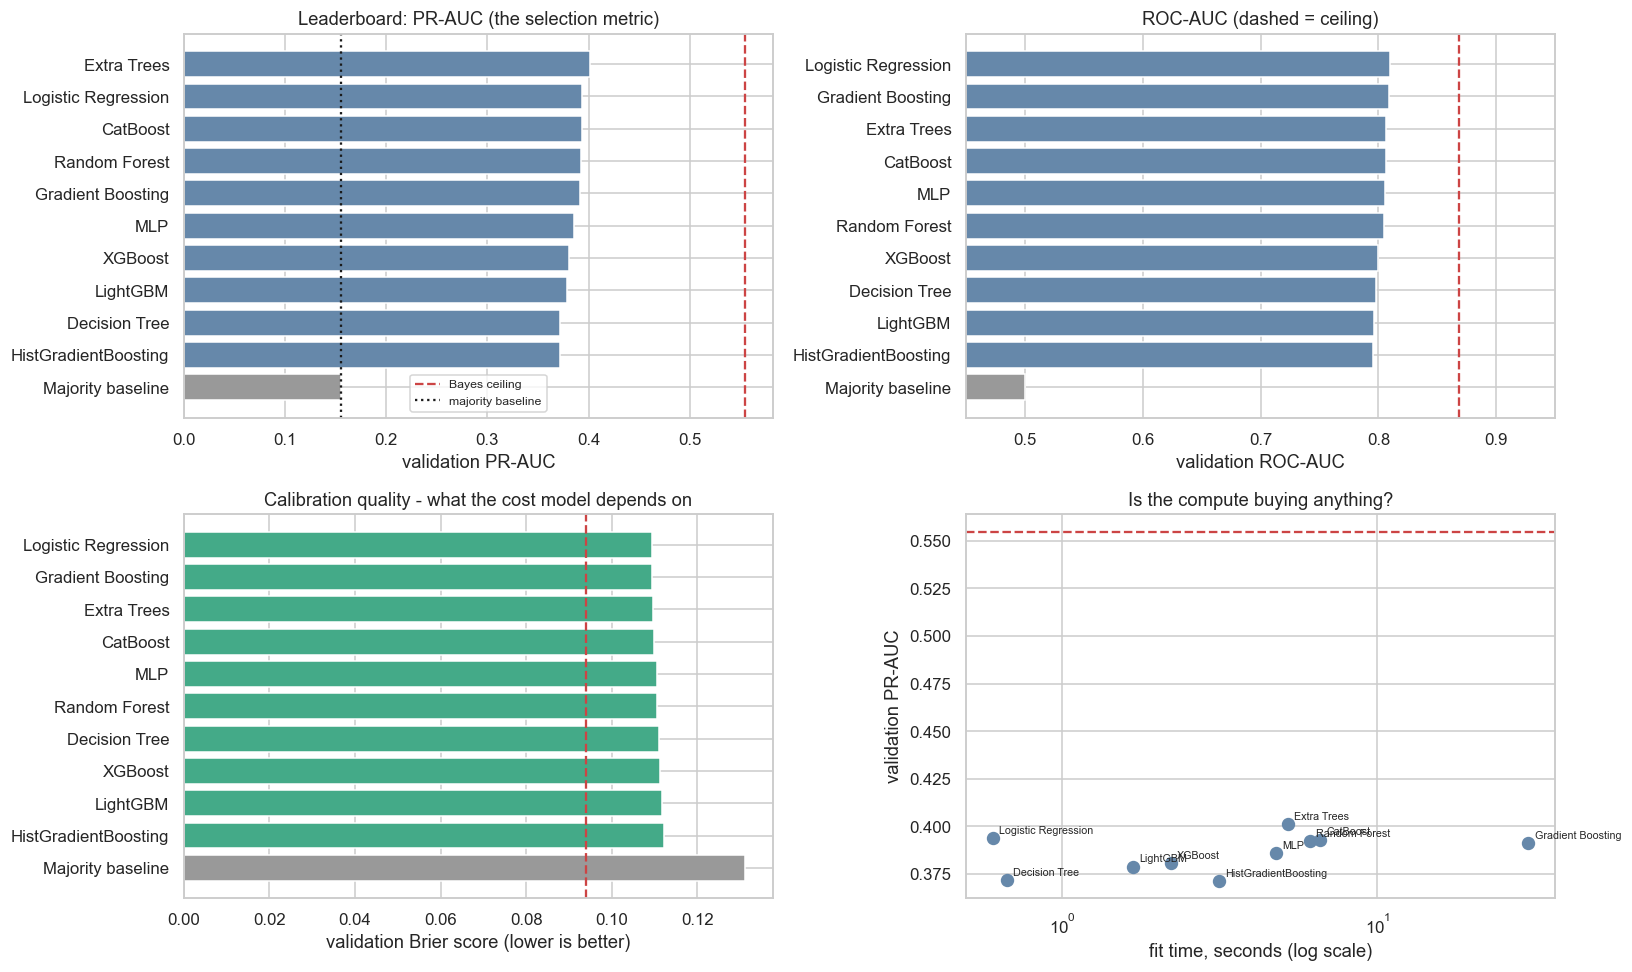

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))

b = board.sort_values("val_pr_auc")
colors = ["#999" if k == "00_dummy" else "#68a" for k in b.key]
ax[0, 0].barh(b.model, b.val_pr_auc, color=colors)
ax[0, 0].axvline(CEILING["pr_auc"], ls="--", c="#c44", lw=1.5, label="Bayes ceiling")
ax[0, 0].axvline(dummy.val_pr_auc, ls=":", c="k", lw=1.5, label="majority baseline")
ax[0, 0].set_xlabel("validation PR-AUC")
ax[0, 0].set_title("Leaderboard: PR-AUC (the selection metric)")
ax[0, 0].legend(fontsize=8)

b2 = board.sort_values("val_roc_auc")
ax[0, 1].barh(b2.model, b2.val_roc_auc,
              color=["#999" if k == "00_dummy" else "#68a" for k in b2.key])
ax[0, 1].axvline(CEILING["roc_auc"], ls="--", c="#c44", lw=1.5)
ax[0, 1].set_xlim(0.45, 0.95)
ax[0, 1].set_xlabel("validation ROC-AUC")
ax[0, 1].set_title("ROC-AUC (dashed = ceiling)")

b3 = board.sort_values("val_brier", ascending=False)
ax[1, 0].barh(b3.model, b3.val_brier,
              color=["#999" if k == "00_dummy" else "#4a8" for k in b3.key])
ax[1, 0].axvline(CEILING["brier"], ls="--", c="#c44", lw=1.5)
ax[1, 0].set_xlabel("validation Brier score (lower is better)")
ax[1, 0].set_title("Calibration quality - what the cost model depends on")

models = board[board.key != "00_dummy"]
ax[1, 1].scatter(models.fit_seconds, models.val_pr_auc, s=60, c="#68a")
for _, r in models.iterrows():
    ax[1, 1].annotate(r.model, (r.fit_seconds, r.val_pr_auc), fontsize=7,
                      xytext=(4, 3), textcoords="offset points")
ax[1, 1].set_xscale("log")
ax[1, 1].axhline(CEILING["pr_auc"], ls="--", c="#c44", lw=1.5)
ax[1, 1].set_xlabel("fit time, seconds (log scale)")
ax[1, 1].set_ylabel("validation PR-AUC")
ax[1, 1].set_title("Is the compute buying anything?")
plt.tight_layout()
plt.savefig(FIG / "03_leaderboard.png", bbox_inches="tight")
plt.show()

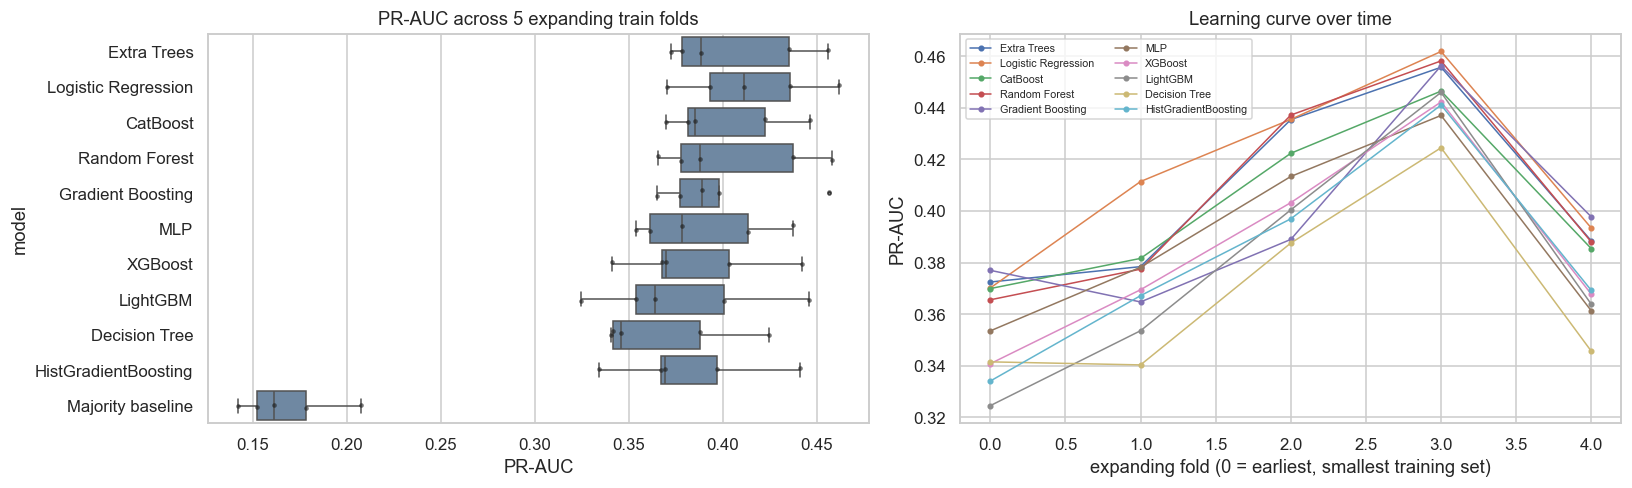

In [19]:
# Fold-level stability. A model that wins on validation but swings across the
# CV folds has not earned the win.
fold_tbl = pd.concat(
    [f.assign(model=zoo[k].label) for k, f in CV_FOLDS.items()], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
order = board.model.tolist()
sns.boxplot(data=fold_tbl, y="model", x="pr_auc", order=order, ax=ax[0],
            color="#68a", fliersize=2)
sns.stripplot(data=fold_tbl, y="model", x="pr_auc", order=order, ax=ax[0],
              color="k", size=3, alpha=0.6)
ax[0].set_title(f"PR-AUC across {N_CV_FOLDS} expanding train folds")
ax[0].set_xlabel("PR-AUC")

for k in board.key:
    if k == "00_dummy":
        continue
    f = CV_FOLDS[k]
    ax[1].plot(f.fold, f.pr_auc, marker="o", ms=3, lw=1, label=zoo[k].label)
ax[1].set_xlabel("expanding fold (0 = earliest, smallest training set)")
ax[1].set_ylabel("PR-AUC")
ax[1].set_title("Learning curve over time")
ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIG / "03_cv_stability.png", bbox_inches="tight")
plt.show()

In [20]:
# Is the leaderboard order real, or is it noise on 5,000 validation orders?
# Paired bootstrap against logistic regression, the simplest serious model.
REF = "01_logistic"
rows = []
for k in board.key:
    if k in (REF, "00_dummy"):
        continue
    d = paired_bootstrap_delta(y_val, VAL_PRED[k], VAL_PRED[REF], seed=SEED)
    rows.append({"model": zoo[k].label, "delta_pr_auc_vs_logreg": d["observed_delta"],
                 "ci_lo": d["ci_lo"], "ci_hi": d["ci_hi"],
                 "p_two_sided": d["p_two_sided"],
                 "beats_logreg": "YES" if d["ci_lo"] > 0 else
                                 ("worse" if d["ci_hi"] < 0 else "no - CI spans 0")})
boot = pd.DataFrame(rows).sort_values("delta_pr_auc_vs_logreg", ascending=False)
display(boot.round(4).style.hide(axis="index"))

model,delta_pr_auc_vs_logreg,ci_lo,ci_hi,p_two_sided,beats_logreg
Extra Trees,0.007400,-0.008300,0.022100,0.387000,no - CI spans 0
CatBoost,-0.000800,-0.013700,0.012100,0.895000,no - CI spans 0
Random Forest,-0.001600,-0.015600,0.012300,0.861000,no - CI spans 0
Gradient Boosting,-0.002600,-0.012400,0.007900,0.664000,no - CI spans 0
MLP,-0.008000,-0.020700,0.005300,0.234000,no - CI spans 0
XGBoost,-0.013300,-0.028600,0.002000,0.088000,no - CI spans 0
LightGBM,-0.015000,-0.033000,0.002900,0.108000,no - CI spans 0
Decision Tree,-0.022200,-0.041500,-0.004700,0.012000,worse
HistGradientBoosting,-0.022500,-0.039200,-0.005600,0.003000,worse


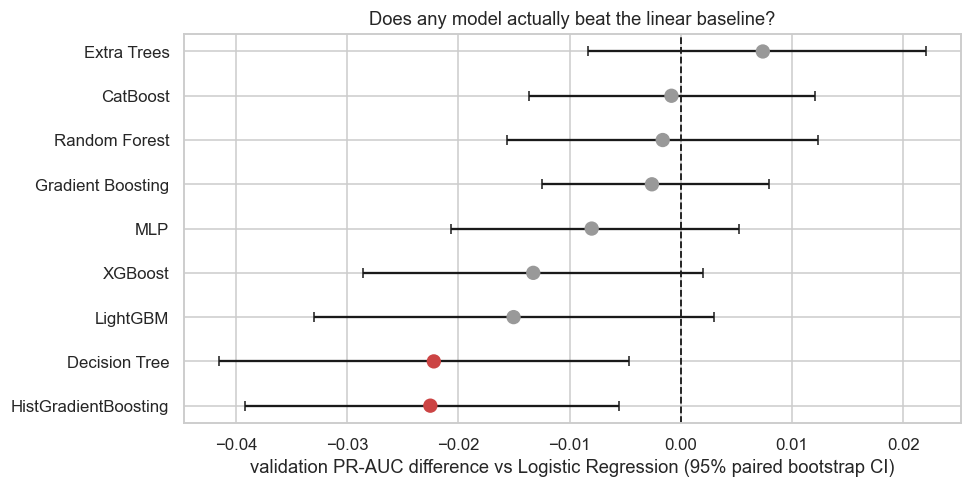

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.6))
b = boot.sort_values("delta_pr_auc_vs_logreg")
y = np.arange(len(b))
colors = ["#4a8" if lo > 0 else ("#c44" if hi < 0 else "#999")
          for lo, hi in zip(b.ci_lo, b.ci_hi)]
ax.errorbar(b.delta_pr_auc_vs_logreg, y,
            xerr=[b.delta_pr_auc_vs_logreg - b.ci_lo, b.ci_hi - b.delta_pr_auc_vs_logreg],
            fmt="o", ecolor="k", capsize=3, ms=0)
ax.scatter(b.delta_pr_auc_vs_logreg, y, c=colors, s=70, zorder=3)
ax.axvline(0, ls="--", c="k", lw=1.2)
ax.set_yticks(y, b.model)
ax.set_xlabel("validation PR-AUC difference vs Logistic Regression (95% paired bootstrap CI)")
ax.set_title("Does any model actually beat the linear baseline?")
plt.tight_layout()
plt.savefig(FIG / "03_bootstrap_vs_logreg.png", bbox_inches="tight")
plt.show()

In [22]:
n_sig_better = int((boot.ci_lo > 0).sum())
n_sig_worse = int((boot.ci_hi < 0).sum())
n_tied = len(boot) - n_sig_better - n_sig_worse

print(f"models significantly BETTER than logistic regression : {n_sig_better}")
print(f"models statistically indistinguishable from it       : {n_tied}")
print(f"models significantly WORSE                           : {n_sig_worse}")
print()
if n_sig_better == 0:
    print("""FINDING, reported as PRE_REGISTRATION.md requires:

  No model in this benchmark beats L2-regularised logistic regression by a
  margin that survives a paired bootstrap on the validation set.

  Why that is not a surprise here, and what it does and does not mean:

  The label-generating process in 01 is ADDITIVE IN LOG-ODDS -- city prior,
  customer latent, address quality, category, discount, ETA and velocity each
  contribute a term, and Bernoulli noise does the rest. A logistic regression on
  those features is close to the correct functional form BY CONSTRUCTION. The
  boosters have to discover that additive structure from data and pay variance
  for flexibility they do not need.

  This is a property of our synthetic generator, NOT evidence that gradient
  boosting is a poor choice for real RTO data, where interactions between
  courier, corridor, seller and season are exactly what a linear model misses.
  We are reporting the result we got, and stating its scope.

  Practical consequence: logistic regression stays in the finalist set. If a
  simple, fast, monotone, trivially explainable model is within noise of the
  boosters, that is a genuine argument in its favour for a checkout-latency
  scorer -- not a consolation prize.""")
else:
    print(f"{n_sig_better} model(s) beat logistic regression with a CI clear of zero.")

models significantly BETTER than logistic regression : 0
models statistically indistinguishable from it       : 7
models significantly WORSE                           : 2

FINDING, reported as PRE_REGISTRATION.md requires:

  No model in this benchmark beats L2-regularised logistic regression by a
  margin that survives a paired bootstrap on the validation set.

  Why that is not a surprise here, and what it does and does not mean:

  The label-generating process in 01 is ADDITIVE IN LOG-ODDS -- city prior,
  customer latent, address quality, category, discount, ETA and velocity each
  contribute a term, and Bernoulli noise does the rest. A logistic regression on
  those features is close to the correct functional form BY CONSTRUCTION. The
  boosters have to discover that additive structure from data and pay variance
  for flexibility they do not need.

  This is a property of our synthetic generator, NOT evidence that gradient
  boosting is a poor choice for real RTO data, where inter

In [23]:
# The class-weight question, settled with numbers rather than a convention.
#
# 02 said we would use class_weight='balanced' where supported. We are NOT doing
# that, and this is the evidence. Reweighting shifts the intercept: it can help
# ranking slightly, and it systematically inflates predicted probabilities. Our
# threshold is chosen on a RUPEE COST CURVE in 05, which needs probabilities that
# mean what they say.
from sklearn.base import clone

weight_rows = []
for k, weighted in [
    ("01_logistic", {"clf__class_weight": "balanced"}),
    ("08_lightgbm", {"clf__class_weight": "balanced"}),
    ("03_random_forest", {"clf__class_weight": "balanced"}),
]:
    for tag, params in [("unweighted", {}), ("class_weight='balanced'", weighted)]:
        pipe = build_pipeline(zoo[k])
        if params:
            pipe.set_params(**params)
        pipe.fit(train[COLS], y_train)
        m = classification_metrics(y_val, pipe.predict_proba(val[COLS])[:, 1])
        weight_rows.append({"model": zoo[k].label, "variant": tag,
                            "val_pr_auc": m["pr_auc"], "val_brier": m["brier"],
                            "mean_predicted_p": m["mean_pred"]})

weights = pd.DataFrame(weight_rows)
weights["actual_base_rate"] = y_val.mean()
display(weights.round(4).style.hide(axis="index"))

model,variant,val_pr_auc,val_brier,mean_predicted_p,actual_base_rate
Logistic Regression,unweighted,0.393900,0.109400,0.154400,0.155000
Logistic Regression,class_weight='balanced',0.391800,0.178900,0.378000,0.155000
LightGBM,unweighted,0.378900,0.111700,0.147700,0.155000
LightGBM,class_weight='balanced',0.382700,0.154400,0.316900,0.155000
Random Forest,unweighted,0.392300,0.110700,0.159100,0.155000
Random Forest,class_weight='balanced',0.389300,0.153300,0.348400,0.155000


In [24]:
pivot_brier = weights.pivot(index="model", columns="variant", values="val_brier")
pivot_pr = weights.pivot(index="model", columns="variant", values="val_pr_auc")
pivot_mean = weights.pivot(index="model", columns="variant", values="mean_predicted_p")

print("Effect of class_weight='balanced':\n")
print(f"{'model':<22} {'d PR-AUC':>10} {'d Brier':>10} {'mean p':>18}")
for m in pivot_brier.index:
    dpr = pivot_pr.loc[m, "class_weight='balanced'"] - pivot_pr.loc[m, "unweighted"]
    dbr = pivot_brier.loc[m, "class_weight='balanced'"] - pivot_brier.loc[m, "unweighted"]
    mp = pivot_mean.loc[m, "class_weight='balanced'"]
    print(f"{m:<22} {dpr:>+10.4f} {dbr:>+10.4f} {mp:>10.3f} vs {y_val.mean():.3f}")

print(f"""
DECISION: no class weighting anywhere in this submission.

Reweighting pushes mean predicted probability far above the true base rate of
{y_val.mean():.3f} and worsens the Brier score, while buying little or nothing in
PR-AUC. We need calibrated probabilities more than we need a balanced-looking
confusion matrix at 0.5 -- because we never operate at 0.5. The threshold moves
on the cost curve instead.

This reverses the note in 02 and is logged as a deviation in WHAT_BROKE.md.""")

Effect of class_weight='balanced':

model                    d PR-AUC    d Brier             mean p
LightGBM                  +0.0038    +0.0427      0.317 vs 0.155
Logistic Regression       -0.0021    +0.0695      0.378 vs 0.155
Random Forest             -0.0030    +0.0426      0.348 vs 0.155

DECISION: no class weighting anywhere in this submission.

Reweighting pushes mean predicted probability far above the true base rate of
0.155 and worsens the Brier score, while buying little or nothing in
PR-AUC. We need calibrated probabilities more than we need a balanced-looking
confusion matrix at 0.5 -- because we never operate at 0.5. The threshold moves
on the cost curve instead.

This reverses the note in 02 and is logged as a deviation in WHAT_BROKE.md.


## 15. Select finalists for tuning

In [25]:
# Selection rule, applied as stated: top 3 by validation PR-AUC, with CV
# stability and Brier as tie-breakers, and at least one non-boosting family kept
# if it is within bootstrap noise of the leader.
candidates = board[board.key != "00_dummy"].copy()
candidates["cv_rank"] = candidates.cv_pr_auc_mean.rank(ascending=False)
candidates["val_rank"] = candidates.val_pr_auc.rank(ascending=False)
candidates["brier_rank"] = candidates.val_brier.rank()
candidates["combined_rank"] = (
    candidates.val_rank + candidates.cv_rank + 0.5 * candidates.brier_rank)

display(candidates[["model", "family", "val_pr_auc", "cv_pr_auc_mean",
                    "cv_pr_auc_std", "val_brier", "combined_rank"]]
        .sort_values("combined_rank").round(4).style.hide(axis="index"))

FINALISTS = (candidates.sort_values(["combined_rank", "val_rank"])
             .head(3).key.tolist())
print("\nFINALISTS for hyperparameter tuning in 04:")
for i, k in enumerate(FINALISTS, 1):
    r = board[board.key == k].iloc[0]
    print(f"  {i}. {zoo[k].label:<24} val PR-AUC {r.val_pr_auc:.4f}  "
          f"CV {r.cv_pr_auc_mean:.4f} +/- {r.cv_pr_auc_std:.4f}  "
          f"Brier {r.val_brier:.4f}  ({r.fit_seconds:.1f}s)")

model,family,val_pr_auc,cv_pr_auc_mean,cv_pr_auc_std,val_brier,combined_rank
Logistic Regression,linear,0.393941,0.414466,0.035715,0.109411,3.500000
Extra Trees,bagging,0.401319,0.406092,0.037185,0.109743,4.500000
CatBoost,boosting,0.393098,0.401165,0.032046,0.109876,9.000000
Random Forest,bagging,0.392313,0.405275,0.040202,0.110673,10.000000
Gradient Boosting,boosting,0.391343,0.396950,0.035417,0.109501,11.000000
MLP,neural,0.385924,0.388695,0.035509,0.110666,14.500000
XGBoost,boosting,0.380670,0.384711,0.039061,0.111332,18.000000
LightGBM,boosting,0.378899,0.377686,0.046843,0.111709,21.500000
Decision Tree,tree,0.371725,0.367925,0.037226,0.111025,22.500000
HistGradientBoosting,boosting,0.371412,0.381714,0.039976,0.112241,23.000000



FINALISTS for hyperparameter tuning in 04:
  1. Logistic Regression      val PR-AUC 0.3939  CV 0.4145 +/- 0.0357  Brier 0.1094  (0.6s)
  2. Extra Trees              val PR-AUC 0.4013  CV 0.4061 +/- 0.0372  Brier 0.1097  (5.2s)
  3. CatBoost                 val PR-AUC 0.3931  CV 0.4012 +/- 0.0320  Brier 0.1099  (6.6s)


In [26]:
families = {zoo[k].family for k in FINALISTS}
print(f"families represented: {sorted(families)}")
print(f"""
The finalist set deliberately spans more than one family. Tuning three variants
of the same booster would tell us how well we can tune a booster, not which
model to ship -- and 04 compares two SEARCH strategies, so the model set needs
to be diverse enough for that comparison to mean something.

Everything below the finalists stays in the report: 05 plots all {len(board)} entries
against the tuned finalists, so nothing that lost is quietly deleted.""")

families represented: ['bagging', 'boosting', 'linear']

The finalist set deliberately spans more than one family. Tuning three variants
of the same booster would tell us how well we can tune a booster, not which
model to ship -- and 04 compares two SEARCH strategies, so the model set needs
to be diverse enough for that comparison to mean something.

Everything below the finalists stays in the report: 05 plots all 11 entries
against the tuned finalists, so nothing that lost is quietly deleted.


## 16. Persist results

In [27]:
board_out = board.copy()
board_out.to_csv(RES / "03_leaderboard.csv", index=False)

# Validation predictions for EVERY entry -- 05 needs them for the comparison
# plots, and keeping them means no model has to be refitted to be reported.
pred_frame = pd.DataFrame({"order_id": val.order_id.to_numpy(), "y_true": y_val})
for k, p in VAL_PRED.items():
    pred_frame[k] = p
pred_frame.to_parquet(RES / "03_val_predictions.parquet", index=False)

fold_tbl.to_csv(RES / "03_cv_folds.csv", index=False)

with open(RES / "03_benchmark_summary.json", "w", encoding="utf-8") as fh:
    json.dump({
        "seed": SEED,
        "n_train": int(len(train)), "n_val": int(len(val)),
        "val_base_rate": float(y_val.mean()),
        "cv": {"scheme": "expanding-window TimeSeriesSplit", "n_splits": N_CV_FOLDS},
        "bayes_ceiling_val": CEILING,
        "leaderboard": board_out.to_dict(orient="records"),
        "bootstrap_vs_logistic": boot.to_dict(orient="records"),
        "class_weight_experiment": weights.to_dict(orient="records"),
        "finalists": FINALISTS,
        "class_weighting_used": False,
    }, fh, indent=2, default=float)

for f in ["03_leaderboard.csv", "03_val_predictions.parquet", "03_cv_folds.csv",
          "03_benchmark_summary.json"]:
    print(f"wrote reports/results/{f}")

wrote reports/results/03_leaderboard.csv
wrote reports/results/03_val_predictions.parquet
wrote reports/results/03_cv_folds.csv
wrote reports/results/03_benchmark_summary.json


In [28]:
print(f"""SUMMARY

  entries benchmarked      {len(board)} (10 models + majority baseline)
  selection metric         validation PR-AUC (fixed in PRE_REGISTRATION.md)
  best                     {best.model} at {best.val_pr_auc:.4f}
  majority baseline        {dummy.val_pr_auc:.4f}
  Bayes ceiling            {CEILING['pr_auc']:.4f}
  headroom captured        {(best.val_pr_auc - dummy.val_pr_auc) / (CEILING['pr_auc'] - dummy.val_pr_auc):.1%}
  models beating logreg
    with a CI clear of 0   {n_sig_better}
  class weighting          none, on calibration grounds (evidence above)
  finalists                {', '.join(zoo[k].label for k in FINALISTS)}

  test set                 NOT OPENED""")

SUMMARY

  entries benchmarked      11 (10 models + majority baseline)
  selection metric         validation PR-AUC (fixed in PRE_REGISTRATION.md)
  best                     Extra Trees at 0.4013
  majority baseline        0.1550
  Bayes ceiling            0.5548
  headroom captured        61.6%
  models beating logreg
    with a CI clear of 0   0
  class weighting          none, on calibration grounds (evidence above)
  finalists                Logistic Regression, Extra Trees, CatBoost

  test set                 NOT OPENED


---

## What 03 established

| | |
|---|---|
| Ranked on | validation PR-AUC, pre-registered |
| Folds | expanding-window `TimeSeriesSplit(5)`, identical for every entry |
| Ceiling check | asserted — no model scored above the oracle, so no leak |
| Leaderboard order | tested with a paired bootstrap, not read as fact |
| Class weighting | dropped, with the Brier evidence for dropping it |
| Losers | kept — `05` plots all 11 entries against the tuned finalists |

**Next:** `04_hyperparameter_tuning.ipynb` — Optuna (multivariate TPE + Hyperband)
against FLAML (BlendSearch/CFO) on identical budget, space and seed.